# HackTheCarbon - Monitoring Africa’s Forest Biomass from Space

- The data is reorganised and a randomsplit applied
- Unet segmentation model is chosen for the dataset with feature extractor being efficient net b3 using imagenet
- Finetuning is done on free kaggle GPU (GPU P100) for 15epochs (takes about 30minutes to finetune and generate submission files

# Install & Imports

In [1]:
!pip install -q segmentation-models-pytorch==0.3.3 timm fastai
!pip install rasterio -q
!pip install -q numpy==1.26.4 --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00:00:0

In [2]:
import os                  # built-in → no need to add
import glob                # built-in → no need to add
import warnings            # built-in → no need to add
from pathlib import Path
import shutil

import timm                # ✅ add
import torch               # ✅ add
import rasterio            # ✅ add
import numpy as np         # ✅ add (numpy)
import torchvision         # ✅ add
import pandas as pd        # ✅ add (pandas)
from tqdm import tqdm      # ✅ add (tqdm)
from fastai.vision.all import *   # ✅ add (fastai)
import segmentation_models_pytorch as smp   # ✅ add
from torch.utils.data import Dataset, DataLoader  # torch (already added)
from segmentation_models_pytorch.encoders import get_encoder  # smp (already added)
from torch.utils.data import Dataset, DataLoader, random_split

In [3]:
#import tqdm,fastai
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("smp:", smp.__version__)
print("timm:", timm.__version__)
#print("fastai:", fastai.__version__)
print("rasterio:", rasterio.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
#print("tqdm:", tqdm.__version__)

torch: 2.6.0+cu124
torchvision: 0.21.0+cu124
smp: 0.3.3
timm: 0.9.2
rasterio: 1.4.3
numpy: 1.26.4
pandas: 2.2.3


# Environment Setting

In [4]:
class Config:
  #n_splits = 3
  seed = 42
  #image_size = 224
  model_name = "efficientnet-b3"
  #batch_size = 16
  #epochs = 10
  #tta = 5
  #num_classes = 2
  # lr = 0.0002 #2e-4

In [5]:
def random_seed(seed_value, use_cuda):
    warnings.filterwarnings('ignore')
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    random.seed(seed_value)
    if use_cuda:
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
random_seed(Config.seed, True)

# Understanding the Data

In [6]:
def inspect_raster(image_path):
    """
    Print detailed info about a raster image.
    
    Args:
        image_path (str): Path to the raster file.
    """
    try:
        with rasterio.open(image_path) as src:
            print(f"Driver: {src.driver}")
            print(f"Coordinate System (CRS): {src.crs}")
            print(f"Width: {src.width} pixels")
            print(f"Height: {src.height} pixels")
            print(f"Number of bands: {src.count}")
            print(f"Band datatypes: {[src.dtypes[i-1] for i in src.indexes]}")
            print(f"Georeferencing Transform: {src.transform}")

            print("\nFull Metadata:")
            for key, value in src.tags().items():
                print(f"  {key}: {value}")

    except rasterio.errors.RasterioIOError as e:
        print(f"Error: Unable to open the image file. {e}")
        print("Please check if the file path is correct and the dataset is properly added.")

image_path="/kaggle/input/hack-the-carbon/test/chips/chip_N00E010_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2021-fv5.0_x100_y116_33MYM.tif"
inspect_raster(image_path)
band_names = [
    "Blue_t1", "Green_t1", "Red_t1", "NIR_t1", "SWIR1_t1", "SWIR2_t1",
    "Blue_t2", "Green_t2", "Red_t2", "NIR_t2", "SWIR1_t2", "SWIR2_t2",
    "Blue_t3", "Green_t3", "Red_t3", "NIR_t3", "SWIR1_t3", "SWIR2_t3"
]
print("\n",band_names)

Driver: GTiff
Coordinate System (CRS): EPSG:4326
Width: 256 pixels
Height: 256 pixels
Number of bands: 18
Band datatypes: ['uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16']
Georeferencing Transform: | 0.00, 0.00, 16.83|
| 0.00,-0.00,-7.92|
| 0.00, 0.00, 1.00|

Full Metadata:
  resolution: 0.0002695
  spec: RasterSpec(epsg=4326, bounds=(16.2187795, -8.228913, 17.8115245, -7.228529), resolutions_xy=(0.0002695, 0.0002695))
  AREA_OR_POINT: Area

 ['Blue_t1', 'Green_t1', 'Red_t1', 'NIR_t1', 'SWIR1_t1', 'SWIR2_t1', 'Blue_t2', 'Green_t2', 'Red_t2', 'NIR_t2', 'SWIR1_t2', 'SWIR2_t2', 'Blue_t3', 'Green_t3', 'Red_t3', 'NIR_t3', 'SWIR1_t3', 'SWIR2_t3']


In [7]:
image_path="/kaggle/input/hack-the-carbon/train/seg_maps/label_N00E010_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2021-fv5.0_x100_y85_33MYP.tif"
inspect_raster(image_path)

Driver: GTiff
Coordinate System (CRS): EPSG:4326
Width: 256 pixels
Height: 256 pixels
Number of bands: 1
Band datatypes: ['float32']
Georeferencing Transform: | 0.00, 0.00, 16.83|
| 0.00,-0.00,-5.80|
| 0.00, 0.00, 1.00|

Full Metadata:
  long_name: band_data
  AREA_OR_POINT: Area


# Data Preparation

In [8]:
# Define paths
root = "/kaggle/input/hack-the-carbon"
source_train_chips = os.path.join(root, "train", "chips")
source_train_seg = os.path.join(root, "train", "seg_maps")
source_val_chips = os.path.join(root, "val", "chips")
source_val_seg = os.path.join(root, "val", "seg_maps")

# Define target directories in Kaggle's working area
working_dir = "/kaggle/working"
target_all_chips = os.path.join(working_dir, "data", "chips")
target_all_seg = os.path.join(working_dir, "data", "seg_maps")

# Create the target directories (this will also create any missing parent directories)
os.makedirs(target_all_chips, exist_ok=True)
os.makedirs(target_all_seg, exist_ok=True)

# Function to copy all files from a source directory to a target directory
def copy_files(source_dir, target_dir):
    for file_name in os.listdir(source_dir):
        source_file = os.path.join(source_dir, file_name)
        target_file = os.path.join(target_dir, file_name)
        # Only copy if it's a file and doesn't already exist in the target (to avoid errors on reruns)
        if os.path.isfile(source_file) and not os.path.exists(target_file):
            shutil.copy2(source_file, target_file)
            # print(f"Copied: {file_name}") # Uncomment to see progress, but it will be verbose

# Copy all the files
print("Copying training chips...")
copy_files(source_train_chips, target_all_chips)
print("Copying training segmentation maps...")
copy_files(source_train_seg, target_all_seg)
print("Copying validation chips...")
copy_files(source_val_chips, target_all_chips)
print("Copying validation segmentation maps...")
copy_files(source_val_seg, target_all_seg)

print("Data consolidation complete!")
print(f"Total chips in combined folder: {len(os.listdir(target_all_chips))}")
print(f"Total seg_maps in combined folder: {len(os.listdir(target_all_seg))}")

Copying training chips...
Copying training segmentation maps...
Copying validation chips...
Copying validation segmentation maps...
Data consolidation complete!
Total chips in combined folder: 3335
Total seg_maps in combined folder: 3335


In [9]:
# ---------- Helper: vegetation indices (CRITICAL - MUST BE INCLUDED) ----------
def compute_indices(chip):
    # chip shape: (18, H, W)
    # Order: [Blue_t1, Green_t1, Red_t1, NIR_t1, SWIR1_t1, SWIR2_t1, ... t2, ... t3]
    indices = []
    for t in range(3):  # 3 timesteps
        b = chip[t*6 + 0].astype(np.float32)
        g = chip[t*6 + 1].astype(np.float32)
        r = chip[t*6 + 2].astype(np.float32)
        nir = chip[t*6 + 3].astype(np.float32)
        swir1 = chip[t*6 + 4].astype(np.float32)
        swir2 = chip[t*6 + 5].astype(np.float32)

        # Avoid division by zero with np.errstate
        with np.errstate(divide='ignore', invalid='ignore'):
            ndvi = (nir - r) / (nir + r + 1e-6)
            ndwi = (g - nir) / (g + nir + 1e-6)
            evi = 2.5 * (nir - r) / (nir + 6*r - 7.5*b + 1)
            nbr = (nir - swir2) / (nir + swir2 + 1e-6)
        indices.extend([ndvi, ndwi, evi, nbr])
    return np.stack(indices, axis=0)  # shape (12, H, W)

# ---------- PyTorch Dataset for the COMBINED data (CORRECTED & COMPLETE) ----------
class CombinedBiomassDataset(Dataset):
    def __init__(self, chips_dir, seg_dir, transform=None):
        """
        chips_dir: path to the directory with all chip images
        seg_dir: path to the directory with all segmentation maps
        transform: optional augmentations to apply
        """
        self.chips_dir = chips_dir
        self.seg_dir = seg_dir
        self.transform = transform
        
        # Get the list of chip files and extract the unique identifiers.
        self.chip_files = sorted([f for f in os.listdir(chips_dir) if f.endswith('.tif')])
        
        # This is the crucial part: Create a mapping from the base filename to the full paths.
        # We assume the segmentation file for a chip has the same unique ID but with 'chip_' replaced by 'label_'.
        self.sample_pairs = [] # This will store tuples: (chip_path, seg_path)
        
        for chip_file in self.chip_files:
            # Construct the expected segmentation filename
            seg_file = chip_file.replace("chip_", "label_")
            chip_path = os.path.join(chips_dir, chip_file)
            seg_path = os.path.join(seg_dir, seg_file)
            
            # Check if the corresponding segmentation file actually exists.
            # This prevents errors if there's a mismatch.
            if os.path.exists(seg_path):
                self.sample_pairs.append((chip_path, seg_path))
            else:
                # This is useful for debugging. You might want to comment it out later.
                print(f"Warning: No segmentation found for chip {chip_file}. Expected {seg_path}")

    def __len__(self):
        # The length is now the number of valid (chip, seg) pairs we found.
        return len(self.sample_pairs)

    def __getitem__(self, idx):
        # Get the paths for this index
        chip_path, seg_path = self.sample_pairs[idx]
        
        # Load and normalize chip
        with rasterio.open(chip_path) as src:
            chip = src.read().astype(np.float32) / 10000.0  # (18, 256, 256)

        # Compute vegetation indices (using our function)
        vi = compute_indices(chip)  # (12, 256, 256)
        # Concatenate raw bands with the computed indices to form the full input
        x = np.concatenate([chip, vi], axis=0) # (30, 256, 256)
        x = torch.tensor(x, dtype=torch.float32)

        # Load the segmentation label from the correct path
        with rasterio.open(seg_path) as src:
            y = src.read(1).astype(np.float32)  # (256, 256)
        y = torch.tensor(y, dtype=torch.float32).unsqueeze(0)  # (1, 256, 256)

        if self.transform:
            x, y = self.transform(x, y)

        return x, y

# ---------- Create the combined dataset and perform a random split ----------
# Define paths to our new combined folders
combined_chips_dir = "/kaggle/working/data/chips"
combined_seg_dir = "/kaggle/working/data/seg_maps"

# Create the full dataset object
print("Creating dataset and validating file pairs...")
full_dataset = CombinedBiomassDataset(chips_dir=combined_chips_dir, seg_dir=combined_seg_dir)

# Check if we found all pairs
print(f"Number of valid chip/segmentation pairs found: {len(full_dataset)}")
expected_total = len(os.listdir(combined_chips_dir))
if len(full_dataset) != expected_total:
    print(f"Warning: Could not find a segmentation for every chip. Chips: {expected_total}, Pairs: {len(full_dataset)}")
else:
    print("Success! All chips have a matching segmentation map.")

Creating dataset and validating file pairs...
Number of valid chip/segmentation pairs found: 3335
Success! All chips have a matching segmentation map.


In [10]:
# Define split sizes (e.g., 80% train, 20% validation)
train_ratio = 0.8
train_size = int(train_ratio * len(full_dataset))
val_size = len(full_dataset) - train_size

# Use torch's random_split to create new train and validation sets
# This is the key step that mixes the geographies.
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# ---------- Create DataLoaders ----------
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Check the sizes
print(f"\nFinal Split:")
print(f"Total samples in combined dataset: {len(full_dataset)}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Let's also verify the input tensor shape is correct (should be 30 channels)
sample_x, sample_y = full_dataset[0]
print(f"\nSample input shape (should be [30, 256, 256]): {sample_x.shape}")
print(f"Sample label shape (should be [1, 256, 256]): {sample_y.shape}")


Final Split:
Total samples in combined dataset: 3335
Training samples: 2668
Validation samples: 667

Sample input shape (should be [30, 256, 256]): torch.Size([30, 256, 256])
Sample label shape (should be [1, 256, 256]): torch.Size([1, 256, 256])


# Define Model

- in_channels=30 lets it take your spectral+index bands.

- classes=1 → biomass map (continuous, not categorical).

- For regression, you’ll want loss=nn.MSELoss() or something like MAE/Huber.

In [11]:
#timm.list_models("eff*")
print(list(smp.encoders.encoders.keys()))

['resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152', 'resnext50_32x4d', 'resnext101_32x4d', 'resnext101_32x8d', 'resnext101_32x16d', 'resnext101_32x32d', 'resnext101_32x48d', 'dpn68', 'dpn68b', 'dpn92', 'dpn98', 'dpn107', 'dpn131', 'vgg11', 'vgg11_bn', 'vgg13', 'vgg13_bn', 'vgg16', 'vgg16_bn', 'vgg19', 'vgg19_bn', 'senet154', 'se_resnet50', 'se_resnet101', 'se_resnet152', 'se_resnext50_32x4d', 'se_resnext101_32x4d', 'densenet121', 'densenet169', 'densenet201', 'densenet161', 'inceptionresnetv2', 'inceptionv4', 'efficientnet-b0', 'efficientnet-b1', 'efficientnet-b2', 'efficientnet-b3', 'efficientnet-b4', 'efficientnet-b5', 'efficientnet-b6', 'efficientnet-b7', 'mobilenet_v2', 'xception', 'timm-efficientnet-b0', 'timm-efficientnet-b1', 'timm-efficientnet-b2', 'timm-efficientnet-b3', 'timm-efficientnet-b4', 'timm-efficientnet-b5', 'timm-efficientnet-b6', 'timm-efficientnet-b7', 'timm-efficientnet-b8', 'timm-efficientnet-l2', 'timm-tf_efficientnet_lite0', 'timm-tf_efficientnet_li

In [12]:
def inspect_encoder(name, in_channels=3, img_size=224):
    # grab encoder config from registry
    enc = smp.encoders.encoders[name]
    
    # available pretrained weights
    pretrained_weights = list(enc["pretrained_settings"].keys())
    
    # default input size (if defined in pretrained settings)
    default_input = None
    if pretrained_weights:
        first_key = pretrained_weights[0]
        default_input = enc["pretrained_settings"][first_key].get("input_size", None)
    
    # build model
    model = get_encoder(name, in_channels=in_channels, depth=5, weights=None)
    params = sum(p.numel() for p in model.parameters())
    out_channels = model.out_channels
    depth = len(out_channels) - 1
    
    # run dummy input
    x = torch.randn(1, in_channels, img_size, img_size)
    with torch.no_grad():
        features = model(x)
    shapes = [tuple(f.shape) for f in features]
    
    return {
        "name": name,
        "params (M)": round(params / 1e6, 2), # → model size
        "depth": depth, # → how many stages
        "out_channels": out_channels, # → channels per stage
        "feature_shapes": shapes, # → real feature maps
        "pretrained_weights": pretrained_weights, #→ what datasets it was trained on
        "default_input": default_input,
    }

efficientnets = [
    "efficientnet-b0", "efficientnet-b1", "efficientnet-b2", 
    "efficientnet-b3", "efficientnet-b4", "efficientnet-b5", 
    "efficientnet-b6", "efficientnet-b7"
]
resnets =['resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152', 'resnext50_32x4d', 
 'resnext101_32x4d', 'resnext101_32x8d', 'resnext101_32x16d', 'resnext101_32x32d',
 'resnext101_32x48d',]

for name in efficientnets:
    print(inspect_encoder(name))
    print()
    pass


for name in resnets:
    #print(inspect_encoder(name))
    #print()
    pass

{'name': 'efficientnet-b0', 'params (M)': 4.01, 'depth': 5, 'out_channels': (3, 32, 24, 40, 112, 320), 'feature_shapes': [(1, 3, 224, 224), (1, 32, 112, 112), (1, 24, 56, 56), (1, 40, 28, 28), (1, 112, 14, 14), (1, 320, 7, 7)], 'pretrained_weights': ['imagenet', 'advprop'], 'default_input': None}

{'name': 'efficientnet-b1', 'params (M)': 6.51, 'depth': 5, 'out_channels': (3, 32, 24, 40, 112, 320), 'feature_shapes': [(1, 3, 224, 224), (1, 32, 112, 112), (1, 24, 56, 56), (1, 40, 28, 28), (1, 112, 14, 14), (1, 320, 7, 7)], 'pretrained_weights': ['imagenet', 'advprop'], 'default_input': None}

{'name': 'efficientnet-b2', 'params (M)': 7.7, 'depth': 5, 'out_channels': (3, 32, 24, 48, 120, 352), 'feature_shapes': [(1, 3, 224, 224), (1, 32, 112, 112), (1, 24, 56, 56), (1, 48, 28, 28), (1, 120, 14, 14), (1, 352, 7, 7)], 'pretrained_weights': ['imagenet', 'advprop'], 'default_input': None}

{'name': 'efficientnet-b3', 'params (M)': 10.7, 'depth': 5, 'out_channels': (3, 40, 32, 48, 136, 384), '

In [13]:
model = smp.Unet(
    encoder_name="efficientnet-b3",  # from timm
    encoder_weights="imagenet",      # pretrained on ImageNet
    in_channels=30,                  
    classes=1,                       # regression map
)
model.to("cuda")
model
print()

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b3-5fb5a3c3.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b3-5fb5a3c3.pth
100%|██████████| 47.1M/47.1M [00:00<00:00, 151MB/s] 


# Finetune

In [14]:
def r2_score(y_pred, y_true):
    """
    Compute R² score for fastai.
    y_pred and y_true are torch tensors.
    """
    y_true_mean = torch.mean(y_true)
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - y_true_mean) ** 2)
    r2 = 1 - ss_res / (ss_tot + 1e-8)  # avoid division by zero
    return r2
def loss_fn(y_pred, y_true):
    return F.mse_loss(y_pred, y_true)

In [15]:
# Convert dataloaders
dls = DataLoaders(train_loader, val_loader)

learn = Learner(
    dls,
    model,
    loss_func=loss_fn,
    metrics=[mae, rmse,r2_score],  # custom metrics possible
)

learn.fine_tune(15)

epoch,train_loss,valid_loss,mae,_rmse,r2_score,time
0,8097.357422,5418.540527,54.408810,73.610733,-0.734007,01:19


epoch,train_loss,valid_loss,mae,_rmse,r2_score,time
0,6849.056152,6508.339355,61.416370,80.674278,-1.094606,01:14
1,6248.370117,9643.825195,80.219490,98.202972,-2.149055,01:13
2,5339.762207,9629.240234,80.194496,98.128693,-2.144050,01:06
3,4137.125977,9490.569336,79.739708,97.419548,-2.102541,01:05
4,2835.301514,3876.001221,48.308235,62.257542,-0.249084,01:04
5,1813.567505,1813.483643,32.187675,42.585018,0.406266,01:04
6,1216.404297,2312.584229,36.653839,48.089333,0.238951,01:02
7,889.770996,1140.312378,25.080667,33.768509,0.620708,01:04
8,729.378967,800.406189,20.580652,28.291451,0.738500,01:04
9,642.024963,1046.167358,21.952751,32.344505,0.669768,01:06


CPU times: user 43 s, sys: 25.4 s, total: 1min 8s
Wall time: 1min 5s


SuggestedLRs(valley=6.30957365501672e-05)

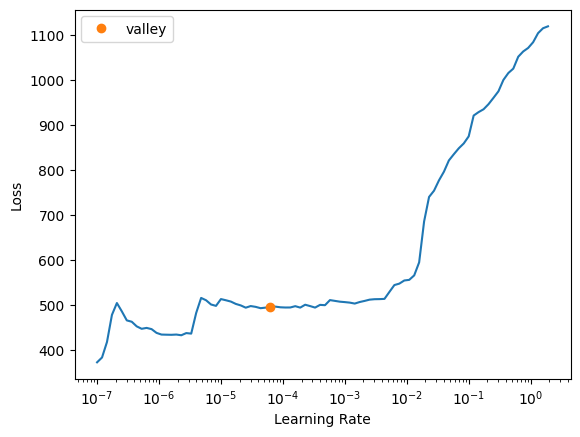

In [16]:
%%time
learn.lr_find()

- fastai suggests a learning rate around 0.00047 (around 500 validation loss)

In [17]:
# ✅ Save only weights
torch.save(model.state_dict(), "unet_weights.pth")

In [18]:
model = smp.Unet(
    encoder_name="efficientnet-b3",   # must match training
    encoder_weights=None,             # don't load pretrained again
    in_channels=30,                   # must match your trained model
    classes=1
)
model.load_state_dict(torch.load("unet_weights.pth", map_location="cpu"))
model.to("cuda")
model.eval()
print()

# Inference

In [19]:
# ---------- Helper: vegetation indices ----------
def compute_indices(chip):
    # chip shape: (18, H, W)
    indices = []
    for t in range(3):  # 3 timesteps
        b = chip[t*6 + 0].astype(np.float32)
        g = chip[t*6 + 1].astype(np.float32)
        r = chip[t*6 + 2].astype(np.float32)
        nir = chip[t*6 + 3].astype(np.float32)
        swir1 = chip[t*6 + 4].astype(np.float32)
        swir2 = chip[t*6 + 5].astype(np.float32)

        with np.errstate(divide='ignore', invalid='ignore'):
            ndvi = (nir - r) / (nir + r + 1e-6)
            ndwi = (g - nir) / (g + nir + 1e-6)
            evi = 2.5 * (nir - r) / (nir + 6*r - 7.5*b + 1)
            nbr = (nir - swir2) / (nir + swir2 + 1e-6)
        indices.extend([ndvi, ndwi, evi, nbr])
    return np.stack(indices, axis=0)  # (12, H, W)


# ---------- Dataset for TEST (no segmentation maps) ----------
class BiomassTestDataset(Dataset):
    def __init__(self, chips_dir):
        self.chips_dir = chips_dir
        self.files = sorted([f for f in os.listdir(chips_dir) if f.endswith(".tif")])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        chip_file = os.path.join(self.chips_dir, self.files[idx])
        
        # Load chip (18 bands)
        with rasterio.open(chip_file) as src:
            chip = src.read().astype(np.float32) / 10000.0  # normalize reflectance
        
        # Compute vegetation indices
        vi = compute_indices(chip)  # (12, H, W)

        # Final stacked input = (30, H, W)
        x = np.concatenate([chip, vi], axis=0)
        x = torch.tensor(x, dtype=torch.float32)

        return x, self.files[idx]  # return filename for saving predictions


# ---------- Example usage ----------
test_chips_dir = "/kaggle/input/hack-the-carbon/test/chips"
test_ds = BiomassTestDataset(test_chips_dir)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

#Check one sample
x, fname = test_ds[0]
print("Input shape:", x.shape)  # should be (30, 256, 256)
print("Filename:", fname)

Input shape: torch.Size([30, 256, 256])
Filename: chip_N00E010_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2021-fv5.0_x100_y116_33MYM.tif


In [20]:
output_dir = "predictions"
os.makedirs(output_dir, exist_ok=True)

with torch.no_grad():
    # Wrap the DataLoader with tqdm
    for x, fnames in tqdm(test_loader, desc="Predicting"):
        for i in range(x.size(0)):
            xi = x[i:i+1].cuda()
            mask = model(xi).squeeze().cpu().numpy()
            mask = mask.astype(np.float32)  # safe dtype

            fname = fnames[i]
            out_name = os.path.splitext(fname)[0].replace("chip_", "prediction_") + ".tif"
            out_path = os.path.join(output_dir, out_name)

            with rasterio.open(
                out_path,
                "w",
                driver="GTiff",
                height=mask.shape[0],
                width=mask.shape[1],
                count=1,
                dtype=mask.dtype
            ) as dst:
                dst.write(mask, 1)

Predicting: 100%|██████████| 947/947 [00:34<00:00, 27.48it/s]


In [21]:
image_path=r'/kaggle/working/predictions/prediction_N00E010_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2021-fv5.0_x100_y116_33MYM.tif'
inspect_raster(image_path)

Driver: GTiff
Coordinate System (CRS): None
Width: 256 pixels
Height: 256 pixels
Number of bands: 1
Band datatypes: ['float32']
Georeferencing Transform: | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|

Full Metadata:


# Prepare Submission - Downsampled Data

In [22]:
from glob import glob
def read_seg_map(seg_map_filename):
  with rasterio.open(seg_map_filename) as dataset:
    image_array = dataset.read()
  return image_array

def downsample_seg_map(input_array, sample_id, ignore_idx=None, kernel_size=4, stride=4):
    if input_array.ndim != 2:
        raise ValueError("Input array must be 2D")

    H, W = input_array.shape
    out_H = (H - kernel_size) // stride + 1
    out_W = (W - kernel_size) // stride + 1

    output = np.zeros((out_H, out_W))
    sample_ids = []
    values = []
    for i in range(out_H):
        for j in range(out_W):
            start_h = i * stride
            end_h = start_h + kernel_size
            start_w = j * stride
            end_w = start_w + kernel_size
            patch = input_array[start_h:end_h, start_w:end_w]
            if ignore_idx is not None:
                patch = np.where(patch == ignore_idx, np.nan, patch)
            if np.any(np.isnan(patch)):
                continue
            else:
                value_at_idx = np.nanmean(patch)
            sample_ids.append(f"{sample_id}_{i}_{j}")
            values.append(np.round(value_at_idx, 0).astype(np.int16) if value_at_idx is not np.nan else np.nan)
    return sample_ids, values

def generate_submission_csv(data_path, ignore_idx=None, output_directory="."):
  prediction_tif_files = glob(os.path.join(data_path, "*.tif"))
  final_sample_ids = []
  final_values = []
  for tif_file in tqdm(prediction_tif_files):
    seg_map = read_seg_map(tif_file).squeeze(0)
    sample_id = os.path.splitext(os.path.basename(tif_file))[0].removeprefix("label_").removeprefix("prediction_")
    sample_ids, values= downsample_seg_map(seg_map, sample_id, ignore_idx=ignore_idx)
    final_sample_ids.extend(sample_ids)
    final_values.extend(values)
  submission_df=pd.DataFrame({'ID':final_sample_ids, 'prediction':final_values}).dropna()
  #submission_df.to_csv(os.path.join(output_directory, 'submission.csv'), index=False)
  submission_df.to_parquet(os.path.join(output_directory,"submission.parquet"), engine="pyarrow", index=False)

  return submission_df

df = generate_submission_csv("predictions")

100%|██████████| 947/947 [02:48<00:00,  5.62it/s]


In [23]:
sample_sub=pd.read_parquet("/kaggle/input/sample-submission-hack-the-carbon/submission_final.parquet")
sub=pd.read_parquet('/kaggle/working/submission.parquet')

sub = sub[sub['ID'].isin(sample_sub['ID'])]

display(
    sub.shape, 
    sub.prediction.nunique(),
    sub.prediction.max(),
    sub.prediction.min(),
    sub.head()
)
sub.fillna(1,inplace=True)
sub.to_parquet('/kaggle/working/submission_final.parquet')

(3641326, 2)

278

278

1

,ID,prediction
0,N00E010_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2021-fv5.0_x103_y127_33LYL_0_0,13
1,N00E010_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2021-fv5.0_x103_y127_33LYL_0_1,14
2,N00E010_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2021-fv5.0_x103_y127_33LYL_0_2,23
3,N00E010_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2021-fv5.0_x103_y127_33LYL_0_3,39
4,N00E010_ESACCI-BIOMASS-L4-AGB-MERGED-100m-2021-fv5.0_x103_y127_33LYL_0_4,50
